0.4922782654984058
CD_WW[i]*10.0 >= ( np.exp(-42.12076509836033) * (M[i])**(55.83243727132408) + 
                                 np.exp(-5699348833.397132) * (M[i])**(-12351176717.108782) + 
                                 np.exp(0.19408281852908896) * (M[i])**(-0.4049955983359361) + 
                                 np.exp(-16.060677946221904) * (M[i])**(22.88210086945111) ),


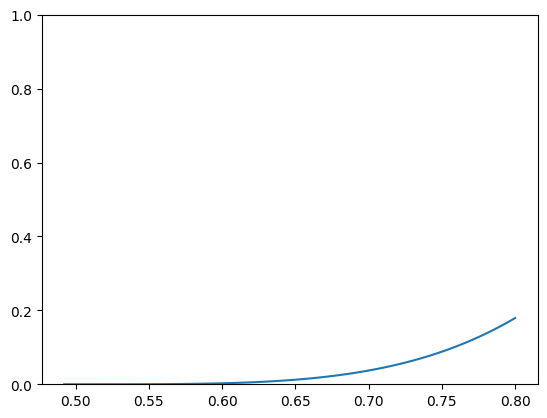

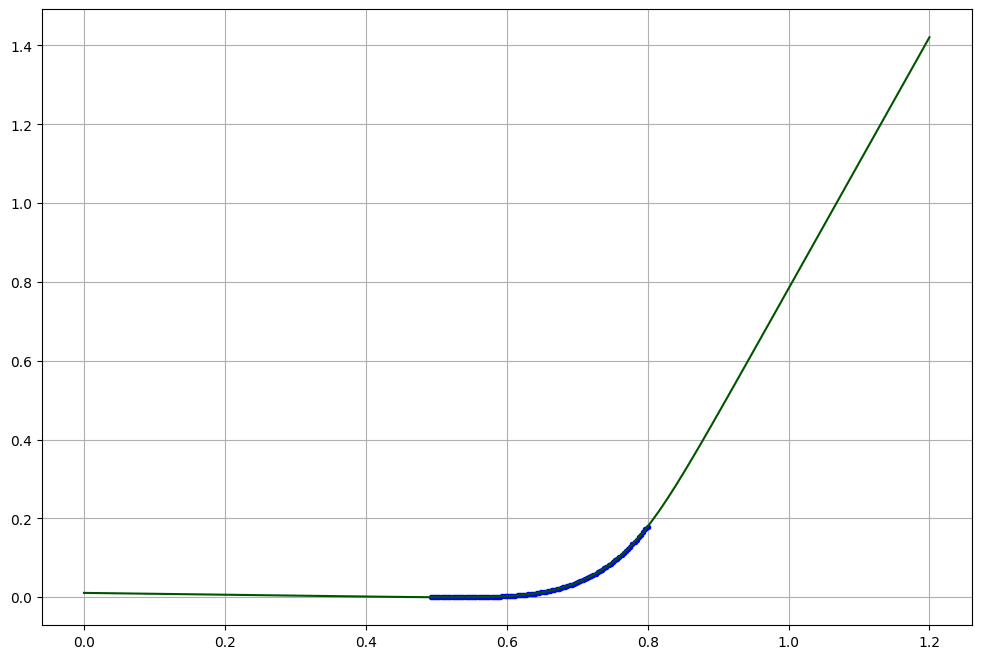

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


MDD = 0.6
Mcrit = MDD - (0.1/80)**(1/3)
print(Mcrit)
M = np.linspace(Mcrit,.8,101)
cdwave = 20*(M-Mcrit)**4
# cdwave2 = 1/(20*(M-Mcrit)**2)

plt.plot(M, cdwave)
# plt.plot(M, cdwave2)

plt.ylim([0,1])




# %matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sfit.convex.softMaxAffine import SoftMaxAffineFitObject as SMAFO
from sfit.convex.implicitSoftMaxAffine import ImplicitSoftMaxAffineFitObject as ISMAFO
# # from sfit.nonconvex.softDifferenceOfMaxAffine import SoftDifferenceOfMaxAffineFitObject as SDMAFO

# queryPoint = 1.25
# queryValue = queryPoint**4 - 3*queryPoint**2
# # ---------------
# x = np.linspace(-2,2,101)
# y = x**4 - 3*x**2
# indp = x.reshape(len(x),1)

# fig = plt.figure(figsize=(12,8))
# plt.plot(x, y,'b.')
# plt.grid(True)
# ---------------
fo = SMAFO()
# M = np.append(np.linspace(0,Mcrit,10),M)
# cdwave = np.append(1e-8*np.ones(10),cdwave)

xdata = [[xv] for xv in M]
ydata = (10*cdwave).tolist()
# print(xdata)
# print(ydata)

fo.fit(xdata, ydata, 4, nfits = 32, randomMean = 0, randomSigma = .2, solverMethod = 'LM')

fig = plt.figure(figsize=(12,8))
plt.plot(xdata, np.array(ydata)/10,'b.')
xdata = [[xv] for xv in np.linspace(0,1.2,101)]
f = fo.evaluate(xdata)
plt.plot([xdata[i][0] for i in range(0,len(xdata))], f/10,ls='-',color=[0,.33,0])
plt.grid(True)

plt.ylim([0,.025])




vns = ['M[i]']
pstr = 'CD_WW[i]*10.0 >= ( ' 
for j in range(0,fo.A.shape[0]):
    if j > 0:
        pstr = pstr + '                               '
    pstr = pstr + 'np.exp(' + str(fo.alpha*fo.b[j]) + ') '
    for i in range(0,fo.A.shape[1]):
        pstr = pstr + '* (' + vns[i] + ')**(' + str(fo.alpha*fo.A[j,i]) + ')'
    if j < fo.A.shape[0]-1:
        pstr += ' + \n  '
pstr += ' ),'

# pstr += '\n'
# pstr += 'P[i,j] <= %f*units.W,\n'%(max2)
print(pstr)